In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error


In [3]:
train_clean = pd.read_csv("../data/train_clean.csv")

In [4]:
train_clean["SalePrice"] = np.log1p(train_clean["SalePrice"])

since it is right skewed we are converting it back to log scale

In [5]:
train_clean["TotalBath"] = (
    train_clean["FullBath"] +
    0.5 * train_clean["HalfBath"] +
    train_clean["BsmtFullBath"] +
    0.5 * train_clean["BsmtHalfBath"]
)

train_clean["TotalSF"] = (
    train_clean["TotalBsmtSF"] +
    train_clean["1stFlrSF"] +
    train_clean["2ndFlrSF"]
)

train_clean["HouseAge"] = train_clean["YrSold"] - train_clean["YearBuilt"]

train_clean["RemodelAge"] = train_clean["YrSold"] - train_clean["YearRemodAdd"]

we are creating more relevent features from existing features for better prediction. This is called feature engineering. A neural network type model automatically performs feature engineering based on its no. of layers and units present in it but since we are doing a linear regression model we need to do it manually.

In [8]:
num_features = train_clean.select_dtypes(include=["int64", "float64"]).columns
train_num = train_clean[num_features]


In [9]:
train_num = train_num.fillna(train_num.median())

In [10]:
x = train_num.drop("SalePrice", axis=1)
y = train_num["SalePrice"]

In [11]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

In [13]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(x_train_scaled, y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","[0.0001, 0.001, ...]"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [14]:
pred = ridge.predict(x_val_scaled)

In [15]:
rmse = np.sqrt(mean_squared_error(y_val, pred))
print("Ridge rmse (log scale): ", rmse)

Ridge rmse (log scale):  0.01194615680743428


In [16]:
real_rmse = np.sqrt(mean_squared_error(np.exp(y_val), np.exp(pred)))
print("Ridge rmse (dollar scale): ", real_rmse)

Ridge rmse (dollar scale):  0.1518844781352068


the rmse value both in log scale and dollar has decreased very significantly using feature engineering beacause of relevant features.

In [17]:
coeff = pd.Series(ridge.coef_, index=x.columns)
coeff.sort_values(ascending=False).head(10)

OverallQual     0.007637
GarageCars      0.003597
OverallCond     0.003479
YearBuilt       0.003053
GrLivArea       0.002733
Fireplaces      0.002615
TotalSF         0.002133
1stFlrSF        0.001968
TotRmsAbvGrd    0.001887
TotalBath       0.001763
dtype: float64

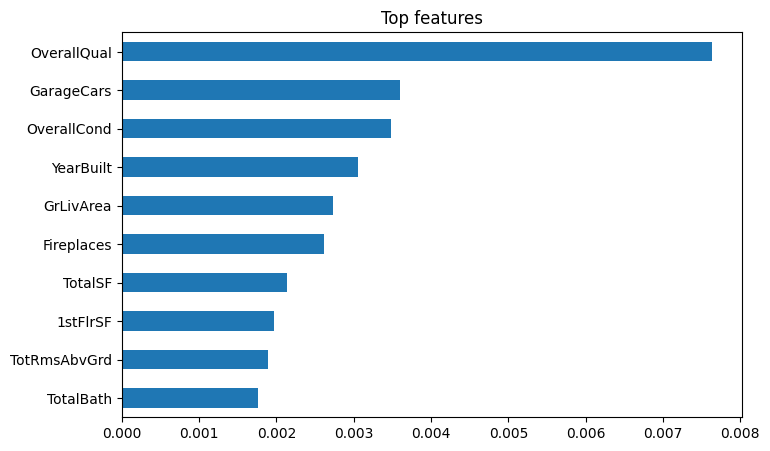

In [23]:
import matplotlib.pyplot as plt

coeff.sort_values().tail(10).plot(kind="barh", figsize=(8, 5))
plt.title("Top features")
plt.show()

this helps to conclude that OverallQual, GarageCars and OverallCond are the largest contributers to predictions.
The features that we created like TotalSf and Total bath are also top contributers in prediction increasing our accuracy.